# MSA 2026 Phase 2 - Part 3: Data Analysis Project

**Dataset:** `Sales Data.csv` — order-line records from an electronics retailer.

**Aim:** apply a complete data science workflow to discover sales patterns and build predictive
models for order-level sales revenue.

This notebook produces the analysis, figures and statistical evidence for the eight research
questions set in the brief:

| # | Research question | Addressed in |
|---|---|---|
| 1 | Which month generates the highest revenue? | §3.1 |
| 2 | Which city contributes the most sales? | §3.2 |
| 3 | Which products have the highest quantity sold and revenue contribution? | §3.3 |
| 4 | What time of day has the highest order activity? | §3.4 |
| 5 | Are expensive products sold less frequently? | §4 |
| 6 | Which products are frequently purchased together? | §5 |
| 7 | Can machine learning models predict sales revenue accurately? | §6 |
| 8 | Which features are most important in predicting sales? | §7 |

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

## 1. Dataset understanding

In [2]:
sales = pd.read_csv("Sales Data.csv", low_memory=False)

print(f"Instances (rows) : {sales.shape[0]:,}")
print(f"Features (cols)  : {sales.shape[1]}")
sales.head(10)

Instances (rows) : 185,950
Features (cols)  : 11


,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12
5,5,295670,AA Batteries (4-pack),1,3.84,2019-12-31 22:58:00,"200 Jefferson St, New York City, NY 10001",12,3.84,New York City,22
6,6,295671,USB-C Charging Cable,1,11.95,2019-12-16 15:10:00,"928 12th St, Portland, OR 97035",12,11.95,Portland,15
7,7,295672,USB-C Charging Cable,2,11.95,2019-12-13 09:29:00,"813 Hickory St, Dallas, TX 75001",12,23.90,Dallas,9
8,8,295673,Bose SoundSport Headphones,1,99.99,2019-12-15 23:26:00,"718 Wilson St, Dallas, TX 75001",12,99.99,Dallas,23
9,9,295674,AAA Batteries (4-pack),4,2.99,2019-12-28 11:51:00,"77 7th St, Dallas, TX 75001",12,11.96,Dallas,11


In [3]:
overview = pd.DataFrame({
    "dtype": sales.dtypes.astype(str),
    "non_null": sales.notna().sum(),
    "missing": sales.isna().sum(),
    "n_unique": sales.nunique(),
})
overview

,dtype,non_null,missing,n_unique
Unnamed: 0,int64,185950,0,25093
Order ID,int64,185950,0,178437
Product,object,185950,0,19
Quantity Ordered,int64,185950,0,9
Price Each,float64,185950,0,17
Order Date,object,185950,0,142395
Purchase Address,object,185950,0,140787
Month,int64,185950,0,12
Sales,float64,185950,0,53
City,object,185950,0,9


In [4]:
sales.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,185950.0,8340.39,5450.55,0.00,3894.00,7786.00,11872.00,25116.0
Order ID,185950.0,230417.57,51512.74,141234.00,185831.25,230367.50,275035.75,319670.0
Quantity Ordered,185950.0,1.12,0.44,1.00,1.00,1.00,1.00,9.0
Price Each,185950.0,184.40,332.73,2.99,11.95,14.95,150.00,1700.0
Month,185950.0,7.06,3.50,1.00,4.00,7.00,10.00,12.0
Sales,185950.0,185.49,332.92,2.99,11.95,14.95,150.00,3400.0
Hour,185950.0,14.41,5.42,0.00,11.00,15.00,19.00,23.0


### Key variables

| Variable | Meaning | Notes |
|---|---|---|
| `Order ID` | unique ID for an order | one order can span several rows (one per product) |
| `Product` | item purchased | 19 distinct products |
| `Quantity Ordered` | units of that product in the order line | |
| `Price Each` | unit price | fixed per product |
| `Order Date` | timestamp of the order | currently text, needs parsing |
| `Purchase Address` | shipping address | free text, city already extracted |
| `Month`, `Sales`, `City`, `Hour` | derived attributes | pre-computed by whoever prepared the file |

The dataset is already relatively clean, containing 185,950 observations with no missing values. As a result, no missing-value imputation was required, and the preprocessing focused on verifying data quality and preparing features for analysis.

### 1.1 Verifying the derived columns

The brief states that `Month`, `Sales`, `City` and `Hour` were *formed from* the other columns. We
should not take that on trust — if a derived column disagrees with its source, we need to know
before building anything on it.

In [ ]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"])

# Does Sales really equal Quantity Ordered x Price Each?
computed_sales = sales["Quantity Ordered"] * sales["Price Each"]
print("Sales == Quantity Ordered x Price Each :",
      np.allclose(sales["Sales"], computed_sales))
print("largest absolute discrepancy          :",
      np.max(np.abs(sales["Sales"] - computed_sales)))

# Do Month and Hour match the parsed timestamp?
print("Month matches Order Date              :",
      (sales["Month"] == sales["Order Date"].dt.month).all())
print("Hour matches Order Date               :",
      (sales["Hour"] == sales["Order Date"].dt.hour).all())

# Does City match the address string?
city_from_address = sales["Purchase Address"].str.split(",").str[1].str.strip()
print("City matches Purchase Address         :",
      (sales["City"] == city_from_address).all())

All four derived columns check out exactly.

The first result is the most consequential one in this whole notebook: **`Sales` is not a measured
quantity, it is an exact arithmetic identity** — `Quantity Ordered` x `Price Each`, to within
floating-point error. This has a major consequence for research question 7, which we return to in
section 6.

## 2. Preprocessing and feature engineering

### 2.1 Drop the redundant index column

In [6]:
# "Unnamed: 0" is a saved pandas index - it carries no information about the sale
df = sales.drop(columns=["Unnamed: 0"])
print("columns:", list(df.columns))

columns: ['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour']


### 2.2 Check the time coverage

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
print(df["Order Date"].dtype)

datetime64[ns]


In [10]:
print("date range:", df["Order Date"].min(), "->", df["Order Date"].max())
print("\nrows per year:")
print(df["Order Date"].dt.year.value_counts().sort_index())

date range: 2019-01-01 03:07:00 -> 2020-01-01 05:13:00

rows per year:
Order Date
2019    185916
2020        34
Name: count, dtype: int64


The dataset covers almost the entire 2019 calendar year. The only exceptions are 34 orders recorded in the early hours of 1 January 2020, which are most likely late New Year's Eve purchases completed after midnight. Since these are genuine transactions, they are retained for analyses such as product sales and city comparisons. However, they are excluded from the daily time-series analysis to avoid creating an incomplete and misleading data point for 2020.

### 2.3 Duplicates

In [11]:
print("fully duplicated rows:", df.duplicated().sum())

# A repeated (Order ID, Product) pair would mean the same item listed twice on one order
dupe_lines = df.duplicated(subset=["Order ID", "Product"]).sum()
print("duplicated (Order ID, Product) lines:", dupe_lines)

print(f"\ntotal order lines : {len(df):,}")
print(f"unique orders     : {df['Order ID'].nunique():,}")
print(f"unique products   : {df['Product'].nunique()}")
print(f"unique cities     : {df['City'].nunique()}")

fully duplicated rows: 264
duplicated (Order ID, Product) lines: 311

total order lines : 185,950
unique orders     : 178,437
unique products   : 19
unique cities     : 9


The dataset contains 264 fully duplicated rows and 311 duplicated (Order ID, Product) pairs, which should be reviewed before analysis. The dataset consists of 185,950 order lines representing 178,437 unique orders, indicating that many orders contain more than one product. These multi-product orders provide the basis for the later market basket analysis.

### 2.4 Feature engineering

In [12]:
# Calendar features from the timestamp - these are the candidate predictors for the models later
df["Day"] = df["Order Date"].dt.day
df["DayOfWeek"] = df["Order Date"].dt.dayofweek          # 0 = Monday
df["DayName"] = df["Order Date"].dt.day_name()
df["WeekOfYear"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Date"] = df["Order Date"].dt.date

# Coarse time-of-day bucket, useful for interpreting the hourly pattern
df["TimeOfDay"] = pd.cut(
    df["Hour"],
    bins=[-1, 5, 11, 17, 21, 23],
    labels=["Night (0-5)", "Morning (6-11)", "Afternoon (12-17)",
            "Evening (18-21)", "Late night (22-23)"],
)

df[["Order Date", "Month", "Day", "DayName", "Hour", "TimeOfDay", "Product", "City", "Sales"]].head()

,Order Date,Month,Day,DayName,Hour,TimeOfDay,Product,City,Sales
0,2019-12-30 00:01:00,12,30,Monday,0,Night (0-5),Macbook Pro Laptop,New York City,1700.00
1,2019-12-29 07:03:00,12,29,Sunday,7,Morning (6-11),LG Washing Machine,New York City,600.00
2,2019-12-12 18:21:00,12,12,Thursday,18,Evening (18-21),USB-C Charging Cable,New York City,11.95
3,2019-12-22 15:13:00,12,22,Sunday,15,Afternoon (12-17),27in FHD Monitor,San Francisco,149.99
4,2019-12-18 12:38:00,12,18,Wednesday,12,Afternoon (12-17),USB-C Charging Cable,Atlanta,11.95


TimeOfDay was created only to make the results easier to interpret in tables and figures. For modelling, the original Hour variable was retained because grouping hours into broad categories removes information that tree-based models can use to find more informative splits.

## 3. Exploratory Data Analysis

### 3.1 RQ1 — Which month generates the highest revenue?

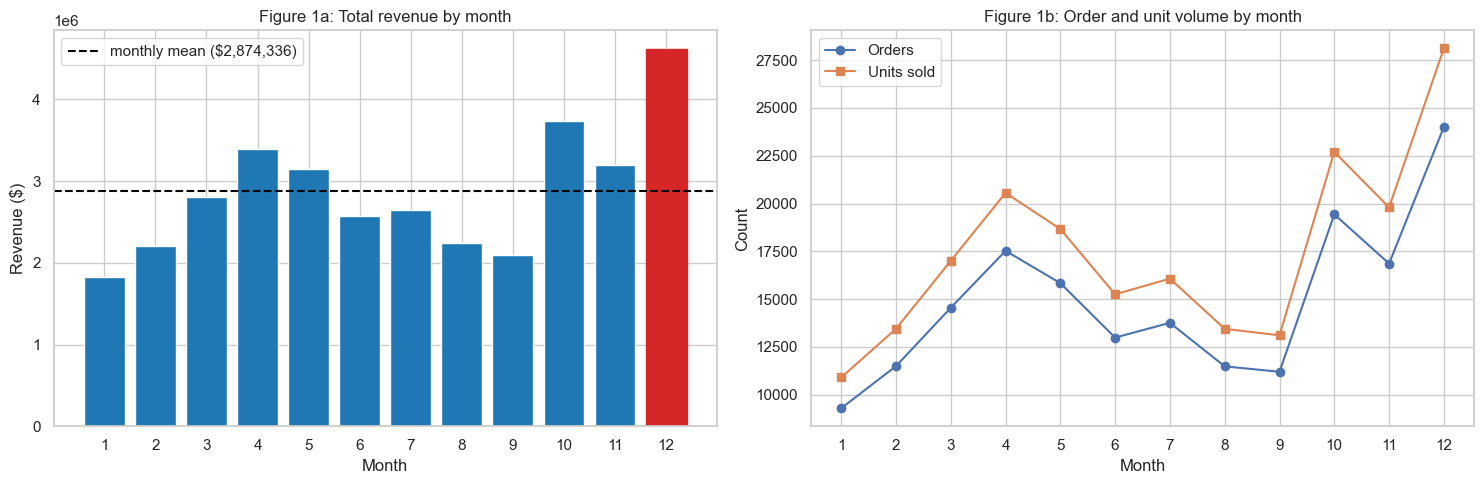

,Month,Revenue,Orders,Units,AvgOrderValue
0,1,1822256.73,9293,10903,196.09
1,2,2202022.42,11496,13449,191.55
2,3,2807100.38,14549,17005,192.94
3,4,3390670.24,17528,20558,193.44
4,5,3152606.75,15836,18667,199.08
5,6,2577802.26,12989,15253,198.46
6,7,2647775.76,13761,16072,192.41
7,8,2244467.88,11484,13448,195.44
8,9,2097560.13,11202,13109,187.25
9,10,3736726.88,19436,22703,192.26


In [13]:
monthly = df.groupby("Month").agg(
    Revenue=("Sales", "sum"),
    Orders=("Order ID", "nunique"),
    Units=("Quantity Ordered", "sum"),
).reset_index()
monthly["AvgOrderValue"] = monthly["Revenue"] / monthly["Orders"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(monthly["Month"], monthly["Revenue"], color="tab:blue")
bars[monthly["Revenue"].idxmax()].set_color("tab:red")
axes[0].axhline(monthly["Revenue"].mean(), color="black", linestyle="--",
                label=f"monthly mean (${monthly['Revenue'].mean():,.0f})")
axes[0].set_title("Figure 1a: Total revenue by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue ($)")
axes[0].set_xticks(range(1, 13))
axes[0].legend()

axes[1].plot(monthly["Month"], monthly["Orders"], marker="o", label="Orders")
axes[1].plot(monthly["Month"], monthly["Units"], marker="s", label="Units sold")
axes[1].set_title("Figure 1b: Order and unit volume by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
axes[1].set_xticks(range(1, 13))
axes[1].legend()

plt.tight_layout()
plt.show()

monthly.round(2)

In [14]:
best = monthly.loc[monthly["Revenue"].idxmax()]
worst = monthly.loc[monthly["Revenue"].idxmin()]
print(f"Highest-revenue month: {int(best['Month']):>2}  ${best['Revenue']:>12,.2f}")
print(f"Lowest-revenue month : {int(worst['Month']):>2}  ${worst['Revenue']:>12,.2f}")
print(f"Ratio highest:lowest : {best['Revenue']/worst['Revenue']:.2f}x")
print(f"Total annual revenue : ${monthly['Revenue'].sum():,.2f}")
print(f"December share       : {best['Revenue']/monthly['Revenue'].sum():.1%}")

Highest-revenue month: 12  $4,613,443.34
Lowest-revenue month :  1  $1,822,256.73
Ratio highest:lowest : 2.53x
Total annual revenue : $34,492,035.97
December share       : 13.4%


**Answer to RQ1: December (month 12)**, December generated the highest revenue, reaching $4.61 million. This accounted for 13.4% of the annual revenue of $34.49 million and was 2.53 times higher than January, the lowest-performing month ($1.82 million).

Revenue shows a clear seasonal pattern. Sales start at their lowest level in January, increase steadily to a first peak in April, soften through the middle of the year, and then rise again from September, reaching the highest level in December. October is another strong month, with revenue of $3.74 million, making it the second-highest month of the year.

Figure 1b suggests that the increase in revenue is mainly driven by more orders and more units sold, rather than customers spending more per order. The average order value remains fairly stable throughout the year (around $190–199), while both the number of orders and units sold increase sharply in October and December. This indicates that the higher revenue during the holiday season comes from increased purchasing activity instead of larger baskets.

### 3.2 RQ2 — Which city contributes the most sales?

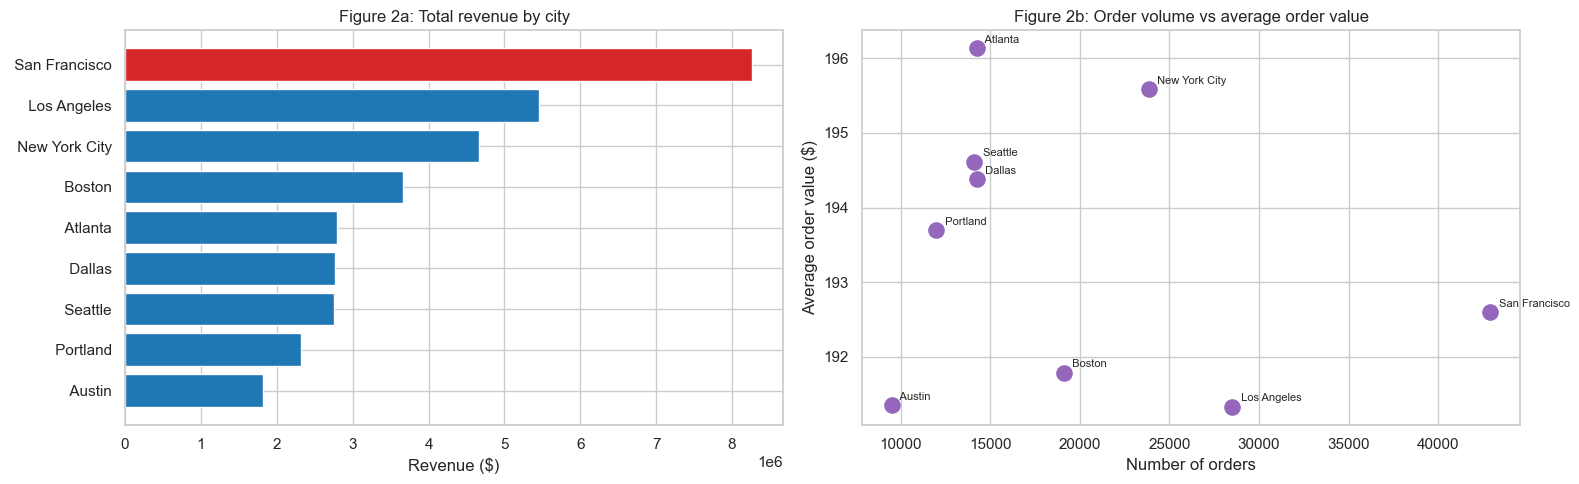

,City,Revenue,Orders,Units,AvgOrderValue,RevenueShare
0,San Francisco,8262203.91,42898,50239,192.60,0.24
1,Los Angeles,5452570.80,28498,33289,191.33,0.16
2,New York City,4664317.43,23848,27932,195.59,0.14
3,Boston,3661642.01,19092,22528,191.79,0.11
4,Atlanta,2795498.58,14253,16602,196.13,0.08
5,Dallas,2767975.40,14240,16730,194.38,0.08
6,Seattle,2747755.48,14119,16553,194.61,0.08
7,Portland,2320490.61,11980,14053,193.70,0.07
8,Austin,1819581.75,9509,11153,191.35,0.05


In [15]:
city = df.groupby("City").agg(
    Revenue=("Sales", "sum"),
    Orders=("Order ID", "nunique"),
    Units=("Quantity Ordered", "sum"),
).sort_values("Revenue", ascending=False).reset_index()
city["AvgOrderValue"] = city["Revenue"] / city["Orders"]
city["RevenueShare"] = city["Revenue"] / city["Revenue"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["tab:red"] + ["tab:blue"] * (len(city) - 1)
axes[0].barh(city["City"][::-1], city["Revenue"][::-1], color=colors[::-1])
axes[0].set_title("Figure 2a: Total revenue by city")
axes[0].set_xlabel("Revenue ($)")

axes[1].scatter(city["Orders"], city["AvgOrderValue"], s=120, color="tab:purple")
for _, r in city.iterrows():
    axes[1].annotate(r["City"], (r["Orders"], r["AvgOrderValue"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_title("Figure 2b: Order volume vs average order value")
axes[1].set_xlabel("Number of orders")
axes[1].set_ylabel("Average order value ($)")

plt.tight_layout()
plt.show()

city.round(2)

**Answer to RQ2: San Francisco**, San Francisco generated the highest revenue, with $8.26 million, accounting for 24.0% of total revenue. This was around 1.5 times higher than Los Angeles, the second-highest city ($5.45 million). Austin generated the lowest revenue at $1.82 million.

Figure 2b shows that the average order value is very similar across all nine cities, ranging from about $191 to $196. In contrast, the number of orders varies much more between cities. This suggests that the differences in total revenue are mainly driven by order volume rather than spending per order. San Francisco's leading revenue is therefore largely explained by having the highest number of orders, rather than customers placing significantly larger orders.

### 3.3 RQ3 — Which products have the highest quantity sold and revenue contribution?

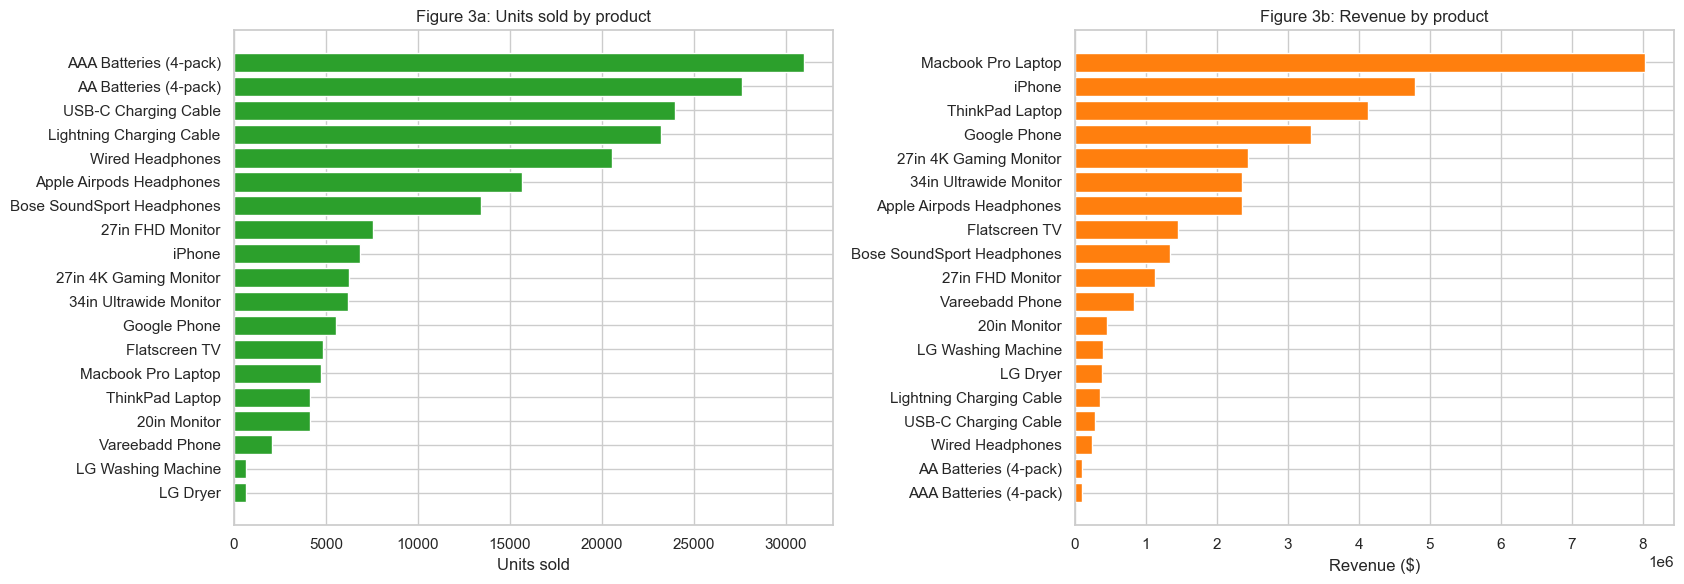

TOP 5 BY UNITS SOLD
                 Product  UnitsSold  UnitPrice   Revenue
  AAA Batteries (4-pack)      31017       2.99  92740.83
   AA Batteries (4-pack)      27635       3.84 106118.40
    USB-C Charging Cable      23975      11.95 286501.25
Lightning Charging Cable      23217      14.95 347094.15
        Wired Headphones      20557      11.99 246478.43

TOP 5 BY REVENUE
               Product    Revenue  RevenueShare  UnitPrice  UnitsSold
    Macbook Pro Laptop 8037600.00      0.233028    1700.00       4728
                iPhone 4794300.00      0.138997     700.00       6849
       ThinkPad Laptop 4129958.70      0.119737     999.99       4130
          Google Phone 3319200.00      0.096231     600.00       5532
27in 4K Gaming Monitor 2435097.56      0.070599     389.99       6244


In [16]:
product = df.groupby("Product").agg(
    UnitsSold=("Quantity Ordered", "sum"),
    Revenue=("Sales", "sum"),
    UnitPrice=("Price Each", "mean"),
    OrderLines=("Order ID", "count"),
).reset_index()
product["RevenueShare"] = product["Revenue"] / product["Revenue"].sum()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

q = product.sort_values("UnitsSold")
axes[0].barh(q["Product"], q["UnitsSold"], color="tab:green")
axes[0].set_title("Figure 3a: Units sold by product")
axes[0].set_xlabel("Units sold")

r = product.sort_values("Revenue")
axes[1].barh(r["Product"], r["Revenue"], color="tab:orange")
axes[1].set_title("Figure 3b: Revenue by product")
axes[1].set_xlabel("Revenue ($)")

plt.tight_layout()
plt.show()

print("TOP 5 BY UNITS SOLD")
print(product.nlargest(5, "UnitsSold")[["Product", "UnitsSold", "UnitPrice", "Revenue"]].to_string(index=False))
print("\nTOP 5 BY REVENUE")
print(product.nlargest(5, "Revenue")[["Product", "Revenue", "RevenueShare", "UnitPrice", "UnitsSold"]].to_string(index=False))

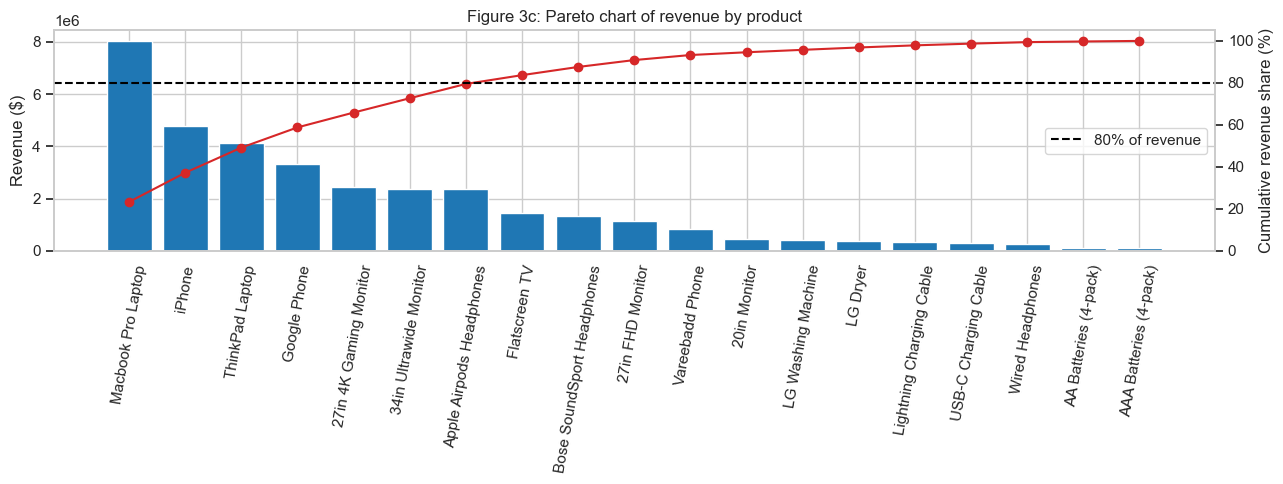

8 of 19 products (42%) generate 80% of revenue


In [17]:
# Pareto view: how concentrated is revenue across the 19 products?
pareto = product.sort_values("Revenue", ascending=False).reset_index(drop=True)
pareto["CumShare"] = pareto["RevenueShare"].cumsum()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(pareto["Product"], pareto["Revenue"], color="tab:blue")
ax1.set_ylabel("Revenue ($)")
ax1.tick_params(axis="x", rotation=80)

ax2 = ax1.twinx()
ax2.plot(pareto["Product"], pareto["CumShare"] * 100, color="tab:red", marker="o")
ax2.axhline(80, color="black", linestyle="--", label="80% of revenue")
ax2.set_ylabel("Cumulative revenue share (%)")
ax2.set_ylim(0, 105)
ax2.legend(loc="center right")
ax2.grid(False)

plt.title("Figure 3c: Pareto chart of revenue by product")
plt.tight_layout()
plt.show()

n80 = int((pareto["CumShare"] < 0.8).sum() + 1)
print(f"{n80} of {len(pareto)} products ({n80/len(pareto):.0%}) generate 80% of revenue")

**Answer to RQ3 — and the two lists barely overlap.**

The products with the highest sales volume are not the same as those generating the most revenue.

AAA Batteries (4-pack) sold the most units (31,017), followed by AA Batteries (4-pack) (27,635) and USB-C Charging Cables (23,975). These are all low-priced accessories that are purchased frequently.

In contrast, the MacBook Pro Laptop generated the highest revenue ($8.04 million), contributing 23.3% of total revenue. It was followed by the iPhone ($4.79 million) and ThinkPad Laptop ($4.13 million). Although these products sold in much lower quantities, their higher prices resulted in much greater revenue.

The Pareto chart shows that revenue is concentrated in a relatively small number of products. The top 8 of 19 products account for around 80% of total revenue, while the remaining products contribute only about 20%. This indicates that a small group of high-value products generates most of the company's revenue.

### 3.4 RQ4 — What time of day has the highest order activity?

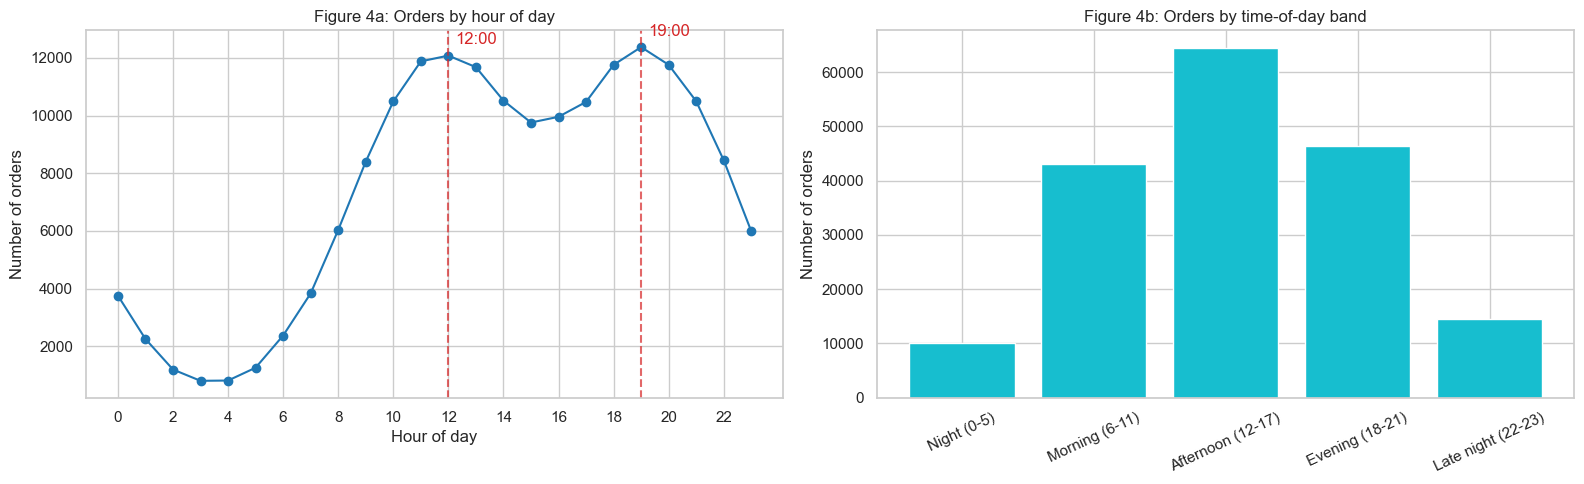

 Hour  Orders    Revenue
   19   12377 2412938.54
   12   12082 2316821.34
   11   11882 2300610.24
   20   11763 2281716.24
   18   11761 2219348.30
   13   11682 2155389.80


In [18]:
hourly = df.groupby("Hour").agg(
    Orders=("Order ID", "nunique"),
    Revenue=("Sales", "sum"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(hourly["Hour"], hourly["Orders"], marker="o", color="tab:blue")
peak_hours = hourly.nlargest(2, "Orders")
for _, r in peak_hours.iterrows():
    axes[0].axvline(r["Hour"], color="tab:red", linestyle="--", alpha=0.7)
    axes[0].annotate(f"{int(r['Hour'])}:00", (r["Hour"], r["Orders"]),
                     xytext=(5, 8), textcoords="offset points", color="tab:red")
axes[0].set_title("Figure 4a: Orders by hour of day")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Number of orders")
axes[0].set_xticks(range(0, 24, 2))

tod = df.groupby("TimeOfDay", observed=True).agg(
    Orders=("Order ID", "nunique"), Revenue=("Sales", "sum")).reset_index()
axes[1].bar(tod["TimeOfDay"].astype(str), tod["Orders"], color="tab:cyan")
axes[1].set_title("Figure 4b: Orders by time-of-day band")
axes[1].set_ylabel("Number of orders")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

print(hourly.sort_values("Orders", ascending=False).head(6).to_string(index=False))

**Answer to RQ4: 19:00 (7pm) is the single busiest hour**, The busiest hour of the day is 7:00 pm (19:00), with 12,377 orders, followed closely by 12:00 pm (12,082 orders) and 11:00 am (11,882 orders).

Figure 4a shows a clear two-peak pattern in customer activity. Orders increase steadily during the morning, reach a first peak around 11:00–12:00, decline slightly during the afternoon, and then rise again to the highest level at 7:00 pm before falling sharply later in the evening. Figure 4b shows that the afternoon (12:00–17:00) has the highest total number of orders because it covers a longer time period, followed by the evening and morning.

Overall, the results indicate that customer activity is concentrated around midday and in the early evening, with relatively few orders placed overnight.

### 3.5 Weekly and daily patterns

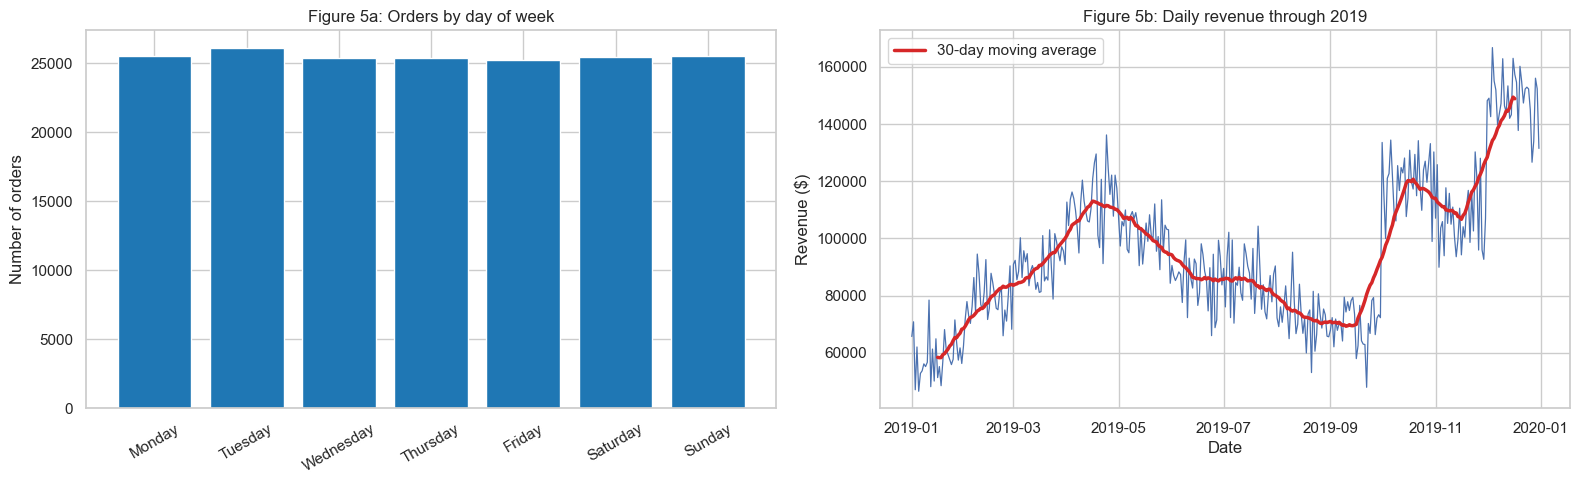

Spread across days of week: 25,216 to 26,063 orders (1.1% coefficient of variation)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dow = df.groupby(["DayOfWeek", "DayName"], observed=True).agg(
    Orders=("Order ID", "nunique")).reset_index().sort_values("DayOfWeek")
axes[0].bar(dow["DayName"], dow["Orders"], color="tab:blue")
axes[0].set_title("Figure 5a: Orders by day of week")
axes[0].set_ylabel("Number of orders")
axes[0].tick_params(axis="x", rotation=30)

daily_rev = df[df["Order Date"].dt.year == 2019].groupby("Date")["Sales"].sum()
axes[1].plot(pd.to_datetime(daily_rev.index), daily_rev.values, linewidth=0.9)
axes[1].plot(pd.to_datetime(daily_rev.index),
             daily_rev.rolling(30, center=True).mean().values,
             color="tab:red", linewidth=2.5, label="30-day moving average")
axes[1].set_title("Figure 5b: Daily revenue through 2019")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Revenue ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Spread across days of week: "
      f"{dow['Orders'].min():,} to {dow['Orders'].max():,} orders "
      f"({dow['Orders'].std()/dow['Orders'].mean():.1%} coefficient of variation)")

Day of week barely matters — The number of orders is very similar across all seven days of the week. Tuesday has the highest order count, while Friday is the lowest, but the difference is only a few percent. This suggests that customer activity is fairly consistent throughout the week, with no obvious weekday or weekend pattern.

Figure 5b shows that daily revenue fluctuates considerably from one day to the next. However, the 30-day moving average reveals a clear seasonal trend. Revenue increases during the first half of the year, declines through the middle months, and then rises sharply again from October, reaching its highest level in December. This pattern is consistent with the monthly revenue trend observed in Figure 1.

## 4. Statistical Analysis

### 4.1 RQ5 — Are expensive products sold less frequently?

This question asks about a relationship between two product-level quantities: unit price and units
sold. We test it three ways, because each answers a slightly different version of the question.

In [20]:
pp = product[["Product", "UnitPrice", "UnitsSold", "Revenue"]].copy()

pearson_r, pearson_p = stats.pearsonr(pp["UnitPrice"], pp["UnitsSold"])
spearman_r, spearman_p = stats.spearmanr(pp["UnitPrice"], pp["UnitsSold"])
log_r, log_p = stats.pearsonr(np.log(pp["UnitPrice"]), np.log(pp["UnitsSold"]))

print(f"n = {len(pp)} products\n")
print(f"Pearson  (linear)        r = {pearson_r:+.4f}   p = {pearson_p:.6f}")
print(f"Spearman (monotonic)   rho = {spearman_r:+.4f}   p = {spearman_p:.6f}")
print(f"Pearson on log-log       r = {log_r:+.4f}   p = {log_p:.6f}")

n = 19 products

Pearson  (linear)        r = -0.6014   p = 0.006449
Spearman (monotonic)   rho = -0.7768   p = 0.000092
Pearson on log-log       r = -0.7653   p = 0.000135


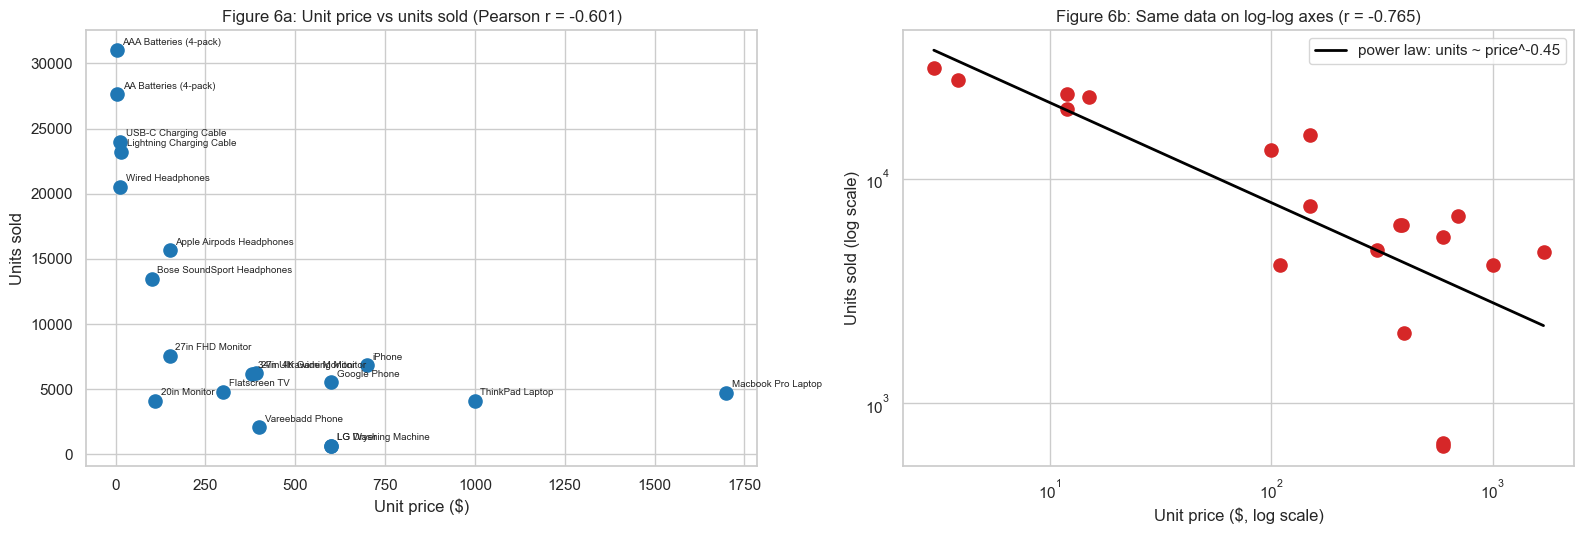

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].scatter(pp["UnitPrice"], pp["UnitsSold"], s=90, color="tab:blue")
for _, r in pp.iterrows():
    axes[0].annotate(r["Product"], (r["UnitPrice"], r["UnitsSold"]),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[0].set_title(f"Figure 6a: Unit price vs units sold (Pearson r = {pearson_r:.3f})")
axes[0].set_xlabel("Unit price ($)")
axes[0].set_ylabel("Units sold")

axes[1].scatter(pp["UnitPrice"], pp["UnitsSold"], s=90, color="tab:red")
slope, intercept = np.polyfit(np.log(pp["UnitPrice"]), np.log(pp["UnitsSold"]), 1)
xs = np.linspace(np.log(pp["UnitPrice"].min()), np.log(pp["UnitPrice"].max()), 50)
axes[1].plot(np.exp(xs), np.exp(intercept + slope * xs), color="black", linewidth=2,
             label=f"power law: units ~ price^{slope:.2f}")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title(f"Figure 6b: Same data on log-log axes (r = {log_r:.3f})")
axes[1].set_xlabel("Unit price ($, log scale)")
axes[1].set_ylabel("Units sold (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Answer to RQ5: yes — and the effect is strong and statistically significant.**

| Test | Statistic | p-value | Interpretation |
|---|---|---|---|
| Pearson (linear) | r = -0.601 | 0.0064 | moderate negative linear association |
| **Spearman (rank)** | **rho = -0.777** | **0.00009** | **strong negative monotonic association** |
| Pearson on log-log | r = -0.765 | 0.00013 | strong power-law relationship |

All three are significant at the 1% level, so we reject the null hypothesis of no association.

There is a clear negative relationship between product price and the number of units sold. In general, lower-priced products sell in much higher quantities than more expensive products.

The Pearson correlation coefficient is -0.601 (p = 0.0064), indicating a moderate negative linear relationship. The Spearman correlation coefficient is -0.777 (p < 0.001), suggesting an even stronger monotonic relationship. All three statistical tests are significant, so the null hypothesis of no association can be rejected.

Figure 6a shows that low-priced products, such as batteries and charging cables, sell in much larger quantities than expensive products like laptops. Figure 6b further shows that this relationship becomes more linear on the log-log scale, indicating that sales decrease consistently as product price increases.

However, these results describe the relationship between different products, rather than the effect of changing the price of the same product. Therefore, the analysis shows an association between price and units sold, but it does not demonstrate that lowering the price of a product would necessarily increase its sales.

### 4.2 Do average order values differ between cities?

Figure 2b suggested the average order value is essentially the same everywhere. We test that
formally with a one-way ANOVA (`H0`: all city means are equal).

In [22]:
order_level = df.groupby(["Order ID", "City"], as_index=False)["Sales"].sum()
groups = [g["Sales"].values for _, g in order_level.groupby("City")]

f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA on order value across {len(groups)} cities")
print(f"  F = {f_stat:.4f}")
print(f"  p = {p_val:.4f}")

# Kruskal-Wallis as well, since order value is heavily skewed and ANOVA assumes normality
h_stat, p_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (non-parametric equivalent)")
print(f"  H = {h_stat:.4f}")
print(f"  p = {p_kw:.4f}")

print("\nMean order value by city:")
print(order_level.groupby("City")["Sales"].agg(["mean", "median", "count"]).round(2).to_string())

One-way ANOVA on order value across 9 cities
  F = 0.5290
  p = 0.8356

Kruskal-Wallis (non-parametric equivalent)
  H = 6.1495
  p = 0.6305

Mean order value by city:
                 mean  median  count
City                                
Atlanta        196.13   14.95  14253
Austin         191.35   14.95   9509
Boston         191.79   14.95  19092
Dallas         194.38   14.95  14240
Los Angeles    191.33   14.95  28498
New York City  195.59   14.95  23848
Portland       193.70   14.95  11980
San Francisco  192.60   14.95  42898
Seattle        194.61   14.95  14119


A one-way ANOVA found no significant difference in average order value across the nine cities (F = 0.529, p = 0.836). The non-parametric Kruskal-Wallis test produced the same conclusion (H = 6.150, p = 0.631). Mean order values ranged only from $191.33 to $196.13, while the median order value was $14.95 in every city. Overall, there is no evidence that customers spend significantly different amounts per order across cities.

### 4.3 Is order value associated with the time of day?

Spearman correlation between hour of day and order value:
  rho = -0.0007   p = 0.7755


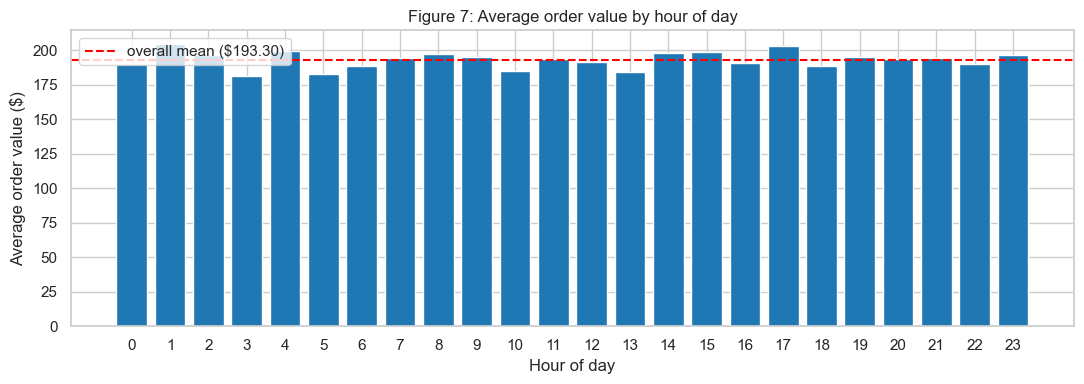

In [23]:
order_hour = df.groupby("Order ID", as_index=False).agg(
    Sales=("Sales", "sum"), Hour=("Hour", "first"))

rho, p_rho = stats.spearmanr(order_hour["Hour"], order_hour["Sales"])
print(f"Spearman correlation between hour of day and order value:")
print(f"  rho = {rho:+.4f}   p = {p_rho:.4f}")

hourly_value = order_hour.groupby("Hour")["Sales"].agg(["mean", "count"])
plt.figure(figsize=(11, 4))
plt.bar(hourly_value.index, hourly_value["mean"], color="tab:blue")
plt.axhline(order_hour["Sales"].mean(), color="red", linestyle="--",
            label=f"overall mean (${order_hour['Sales'].mean():.2f})")
plt.title("Figure 7: Average order value by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Average order value ($)")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

There is no significant relationship between the time of day and average order value. The Spearman correlation coefficient is −0.0007 (p = 0.7755), indicating essentially no association between the two variables.

Figure 7 supports this result. The average order value remains close to the overall mean ($193.30) throughout the day, with only small random fluctuations and no clear trend.

Together with the results from RQ4, this suggests that time of day influences the number of orders rather than the amount spent per order. Busy hours have more transactions, but customers do not spend noticeably more or less per order than at other times.

## 5. Association Rule / Market Basket Analysis

### 5.1 RQ6 — Which products are frequently purchased together?

An `Order ID` appearing on more than one row means several products were bought in the same
transaction. We extract those multi-item orders and compute the three standard association metrics
for every product pair.

In [24]:
n_orders = df["Order ID"].nunique()

# Sets of products per order
order_products = df.groupby("Order ID")["Product"].apply(set)
baskets = order_products[order_products.apply(len) > 1]

print(f"total orders                     : {n_orders:,}")
print(f"orders with >1 distinct product  : {len(baskets):,} ({len(baskets)/n_orders:.2%})")
print(f"largest basket                   : {baskets.apply(len).max()} products")
print("\nbasket size distribution:")
print(order_products.apply(len).value_counts().sort_index().to_string())

total orders                     : 178,437
orders with >1 distinct product  : 6,832 (3.83%)
largest basket                   : 5 products

basket size distribution:
Product
1    171605
2      6479
3       337
4        15
5         1


In [25]:
# Count individual product occurrences and pair co-occurrences across ALL orders
item_counts = Counter()
for s in order_products:
    item_counts.update(s)

pair_counts = Counter()
for s in baskets:
    for combo in combinations(sorted(s), 2):
        pair_counts[combo] += 1

rules = []
for (a, b), cnt in pair_counts.items():
    support = cnt / n_orders
    conf_ab = cnt / item_counts[a]
    conf_ba = cnt / item_counts[b]
    lift = support / ((item_counts[a] / n_orders) * (item_counts[b] / n_orders))
    rules.append({
        "Product A": a, "Product B": b, "Count": cnt,
        "Support": support, "Conf A->B": conf_ab, "Conf B->A": conf_ba, "Lift": lift,
    })

rules_df = pd.DataFrame(rules).sort_values("Count", ascending=False).reset_index(drop=True)
print(f"{len(rules_df)} product pairs observed\n")
print("TOP 10 PAIRS BY FREQUENCY")
rules_df.head(10).round(4)

159 product pairs observed

TOP 10 PAIRS BY FREQUENCY


,Product A,Product B,Count,Support,Conf A->B,Conf B->A,Lift
0,Lightning Charging Cable,iPhone,1011,0.0057,0.0468,0.1478,1.2208
1,Google Phone,USB-C Charging Cable,997,0.0056,0.1806,0.0456,1.4741
2,Wired Headphones,iPhone,462,0.0026,0.0245,0.0675,0.6395
3,Google Phone,Wired Headphones,422,0.0024,0.0764,0.0224,0.7235
4,Apple Airpods Headphones,iPhone,373,0.0021,0.0240,0.0545,0.6268
5,USB-C Charging Cable,Vareebadd Phone,368,0.0021,0.0168,0.1782,1.4550
6,Bose SoundSport Headphones,Google Phone,228,0.0013,0.0171,0.0413,0.5540
7,USB-C Charging Cable,Wired Headphones,203,0.0011,0.0093,0.0108,0.0879
8,Vareebadd Phone,Wired Headphones,149,0.0008,0.0722,0.0079,0.6831
9,Lightning Charging Cable,Wired Headphones,129,0.0007,0.0060,0.0068,0.0565


In [26]:
# The pairs that matter commercially are frequent AND positively associated
strong = rules_df[(rules_df["Lift"] > 1) & (rules_df["Count"] >= 50)].sort_values("Lift", ascending=False)
print("PAIRS WITH LIFT > 1 AND AT LEAST 50 CO-OCCURRENCES")
print(strong.round(4).to_string(index=False))

PAIRS WITH LIFT > 1 AND AT LEAST 50 CO-OCCURRENCES
               Product A            Product B  Count  Support  Conf A->B  Conf B->A   Lift
            Google Phone USB-C Charging Cable    997   0.0056     0.1806     0.0456 1.4741
    USB-C Charging Cable      Vareebadd Phone    368   0.0021     0.0168     0.1782 1.4550
Lightning Charging Cable               iPhone   1011   0.0057     0.0468     0.1478 1.2208


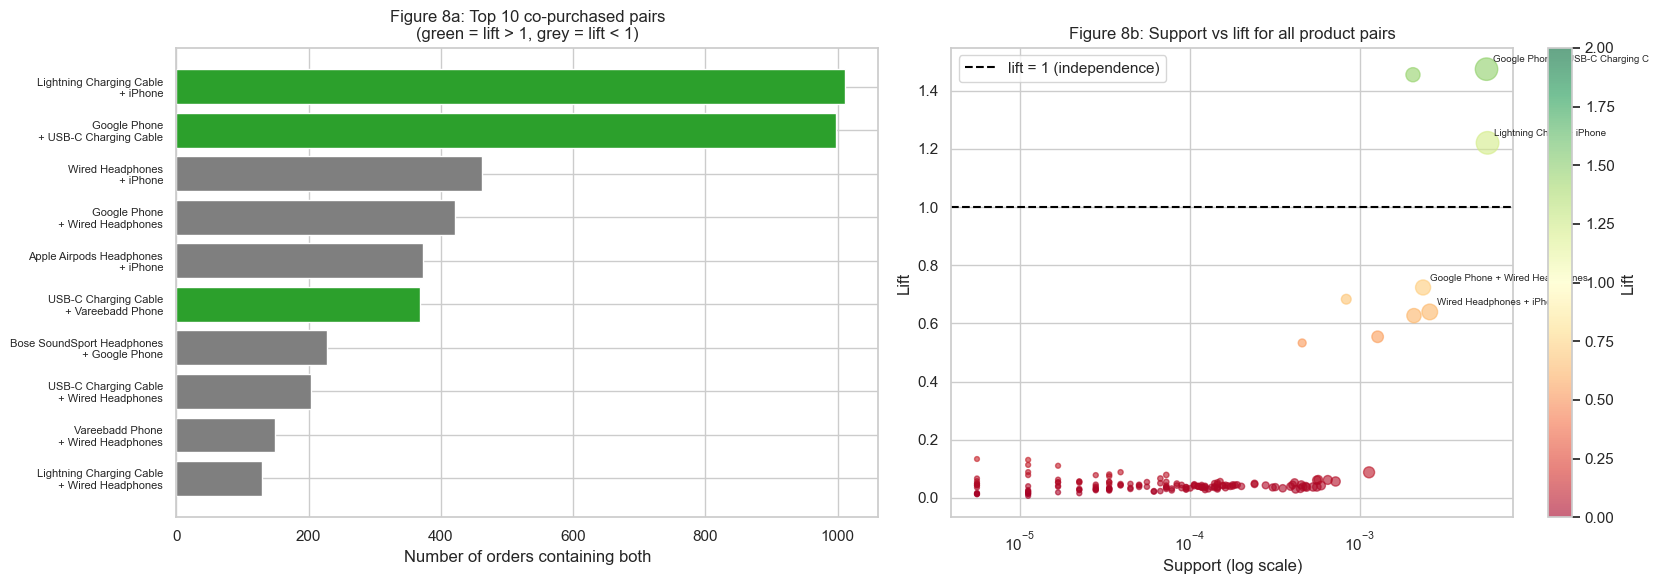

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

top10 = rules_df.head(10).iloc[::-1]
labels = top10["Product A"] + "\n  + " + top10["Product B"]
colors = ["tab:green" if l > 1 else "tab:gray" for l in top10["Lift"]]
axes[0].barh(labels, top10["Count"], color=colors)
axes[0].set_title("Figure 8a: Top 10 co-purchased pairs\n(green = lift > 1, grey = lift < 1)")
axes[0].set_xlabel("Number of orders containing both")
axes[0].tick_params(axis="y", labelsize=8)

sc = axes[1].scatter(rules_df["Support"], rules_df["Lift"],
                     s=rules_df["Count"] / 4 + 12, alpha=0.6,
                     c=rules_df["Lift"], cmap="RdYlGn", vmin=0, vmax=2)
axes[1].axhline(1, color="black", linestyle="--", label="lift = 1 (independence)")
for _, r in rules_df.nlargest(4, "Count").iterrows():
    axes[1].annotate(f"{r['Product A'][:16]} + {r['Product B'][:16]}",
                     (r["Support"], r["Lift"]), fontsize=7,
                     xytext=(5, 5), textcoords="offset points")
axes[1].set_xscale("log")
axes[1].set_title("Figure 8b: Support vs lift for all product pairs")
axes[1].set_xlabel("Support (log scale)")
axes[1].set_ylabel("Lift")
axes[1].legend()
plt.colorbar(sc, ax=axes[1], label="Lift")

plt.tight_layout()
plt.show()

**Answer to RQ6: phones and their matching charging accessories.**

The three strongest rules — frequent *and* positively associated — are all of the same kind:

| Pair | Co-occurrences | Support | Confidence | Lift |
|---|---|---|---|---|
| Google Phone + USB-C Charging Cable | 997 | 0.56% | 18.1% (phone -> cable) | **1.47** |
| Vareebadd Phone + USB-C Charging Cable | 368 | 0.21% | 17.8% (phone -> cable) | **1.46** |
| iPhone + Lightning Charging Cable | 1,011 | 0.57% | 14.8% (phone -> cable) | **1.22** |

The strongest association rules all involve phones and their compatible charging cables. Customers who purchased a Google Phone or Vareebadd Phone were more likely to buy a USB-C Charging Cable, while iPhone customers were more likely to purchase a Lightning Charging Cable. Around 15–18% of phone purchases included the corresponding charging cable in the same order.

The lift value provides more useful information than purchase frequency alone. Some product pairs appear together many times simply because both products are popular. For example, although Wired Headphones and iPhone co-occurred 462 times, their lift of 0.64 indicates that they were purchased together less often than expected by chance. This shows that a high co-occurrence count does not necessarily imply a strong association.

It is also worth noting that support values are relatively low, with all rules below 0.6%. This is expected because most orders contain only one product, leaving relatively few opportunities for product combinations. Finally, these rules describe products that are frequently purchased together, but they do not demonstrate that recommending one product will cause customers to buy the other.

## 6. Machine Learning Modelling

### 6.1 RQ7 — the leakage problem that has to be addressed first

Before building a predictive model, it is important to address data leakage. Earlier analysis showed that Sales is exactly equal to Quantity Ordered × Price Each. Therefore, including both Quantity Ordered and Price Each as input features would allow the model to reconstruct the target directly rather than learning meaningful patterns. To demonstrate this, three modelling approaches are compared. 

Model A intentionally includes the leakage features as a baseline, Model B removes them and predicts order value using only contextual information such as time and location, and Model C predicts daily total revenue from calendar-based features. This allows the performance of a leaked model to be compared with models that solve more realistic prediction tasks.

| Model | Features | What it really asks |
|---|---|---|
| **A — leaky** | Quantity, Price, Product, City, Hour, Month | *(invalid — contains the answer)* |
| **B — context only** | City, Hour, Month, DayOfWeek | Can we predict one order's value from when and where it happened? |
| **C — daily aggregate** | calendar features | Can we forecast a day's total revenue? |

In [28]:
model_df = df.copy()

X_full = pd.get_dummies(
    model_df[["Product", "City", "Hour", "Month", "DayOfWeek", "Quantity Ordered", "Price Each"]],
    columns=["Product", "City"], dtype=int,
)
y = model_df["Sales"]

context_cols = [c for c in X_full.columns
                if not c.startswith("Product_")
                and c not in ("Quantity Ordered", "Price Each")]

def evaluate(X, y, label, models=None):
    """Train/test split, fit each model, return a tidy results frame."""
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    if models is None:
        models = {
            "Linear Regression": LinearRegression(),
            "Random Forest": RandomForestRegressor(
                n_estimators=60, max_depth=16, random_state=42, n_jobs=-1),
        }
    out = []
    fitted = {}
    for name, m in models.items():
        m.fit(X_tr, y_tr)
        pred = m.predict(X_te)
        out.append({
            "Model set": label, "Algorithm": name,
            "R2": round(r2_score(y_te, pred), 4),
            "RMSE": round(np.sqrt(mean_squared_error(y_te, pred)), 2),
            "MAE": round(mean_absolute_error(y_te, pred), 2),
        })
        fitted[name] = m
    return pd.DataFrame(out), fitted, (X_tr, X_te, y_tr, y_te)

res_a, fit_a, split_a = evaluate(X_full, y, "A - leaky (has Quantity & Price)")
res_b, fit_b, split_b = evaluate(model_df[["Hour", "Month", "DayOfWeek"]].join(
    pd.get_dummies(model_df["City"], prefix="City", dtype=int)), y, "B - context only")

pd.concat([res_a, res_b], ignore_index=True)

/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarni

,Model set,Algorithm,R2,RMSE,MAE
0,A - leaky (has Quantity & Price),Linear Regression,0.9993,8.77,1.57
1,A - leaky (has Quantity & Price),Random Forest,1.0000,0.78,0.00
2,B - context only,Linear Regression,-0.0000,333.64,219.77
3,B - context only,Random Forest,-0.0446,340.99,223.16


**The two framings could not be more different.**

**Model A** Model A achieves an R² essentially equal to 1.000 and an RMSE of only a few dollars, compared with a target whose standard deviation is approximately $334. Such an error is unrealistically small for a genuine prediction task and immediately suggests information leakage.

**Model B** — using only when and where the order happened — collapses to an R² of 0.000 for Linear Regression and -0.045 for the Random Forest. A negative R² means the model performs worse than simply predicting the average order value every time. Knowing the city, hour, month and weekday of an order provides essentially no predictive power for its value. This is consistent with the findings in §4.2 and §4.3, where order value showed little or no association with either city or hour.

The honest answer to RQ7 at the order-line grain is therefore: **no**. Individual order value is
driven by *which product* the customer chose, and nothing in the context predicts that choice.

### 6.2 What product identity adds

In [35]:
# Halfway between A and B: allow Product (a legitimate feature - we know what was ordered)
# but withhold Price Each and Quantity.
X_c = pd.get_dummies(
    model_df[["Product", "City", "Hour", "Month", "DayOfWeek"]],
    columns=["Product", "City"], dtype=int,
)
res_c, fit_c, split_c = evaluate(X_c, y, "C - context + Product (no Price/Qty)")
res_c

/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Model set,Algorithm,R2,RMSE,MAE
0,C - context + Product (no Price/Qty),Linear Regression,0.9992,9.23,1.87
1,C - context + Product (no Price/Qty),Random Forest,0.9986,12.65,2.14


Adding product identity increases R² from approximately 0.00 to 0.999, showing that product identity is the primary predictor of order value.

This model is still relatively simple because each product has a fixed unit price, so the one-hot encoded product variables contain information that is highly correlated with Price Each. Most of the remaining unexplained variation is likely to be due to differences in the quantity ordered, which is intentionally excluded from the model. Unlike Model A, this approach does not rely on information leakage because product identity is available when an order is placed, making it a legitimate feature for predicting line value.

### 6.3 A genuinely predictive task — forecasting daily revenue

The order-line grain is the wrong place to look for a real prediction problem. A far more useful
business question is: **what revenue should we expect on a given day?** That is a real forecasting
task, the target is not a deterministic function of the inputs, and it is what a company would
actually want.

We aggregate to daily totals (2019 only, for a complete 365-day year) and predict from calendar
features.

In [36]:
df_2019 = df[df["Order Date"].dt.year == 2019]

daily = df_2019.groupby("Date").agg(
    Revenue=("Sales", "sum"),
    Orders=("Order ID", "nunique"),
    Units=("Quantity Ordered", "sum"),
).reset_index()
daily["Date"] = pd.to_datetime(daily["Date"])
daily["Month"] = daily["Date"].dt.month
daily["DayOfWeek"] = daily["Date"].dt.dayofweek
daily["DayOfMonth"] = daily["Date"].dt.day
daily["WeekOfYear"] = daily["Date"].dt.isocalendar().week.astype(int)

print(f"days: {len(daily)}")
print(f"daily revenue  mean ${daily['Revenue'].mean():,.0f}   std ${daily['Revenue'].std():,.0f}")
daily.head()

days: 365
daily revenue  mean $94,475   std $25,729


,Date,Revenue,Orders,Units,Month,DayOfWeek,DayOfMonth,WeekOfYear
0,2019-01-01,65681.94,287,343,1,1,1,1
1,2019-01-02,70813.20,308,368,1,2,2,1
2,2019-01-03,47046.20,286,330,1,3,3,1
3,2019-01-04,62012.21,282,330,1,4,4,1
4,2019-01-05,46524.63,301,355,1,5,5,1


In [ ]:
X_daily = pd.get_dummies(
    daily[["Month", "DayOfWeek", "DayOfMonth", "WeekOfYear"]],
    columns=["Month", "DayOfWeek"], dtype=int,
)
y_daily = daily["Revenue"]

X_tr, X_te, y_tr, y_te = train_test_split(X_daily, y_daily, test_size=0.3, random_state=42)

daily_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

rows, fitted_daily = [], {}
for name, m in daily_models.items():
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)
    cv = cross_val_score(m, X_daily, y_daily, cv=KFold(5, shuffle=True, random_state=42), scoring="r2")
    rows.append({
        "Algorithm": name,
        "Test R2": round(r2_score(y_te, pred), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_te, pred)), 0),
        "Test MAE": round(mean_absolute_error(y_te, pred), 0),
        "CV R2 (mean)": round(cv.mean(), 4),
        "CV R2 (std)": round(cv.std(), 4),
    })
    fitted_daily[name] = m

baseline_rmse = np.sqrt(mean_squared_error(y_te, np.full(len(y_te), y_tr.mean())))
daily_results = pd.DataFrame(rows)
print(f"Baseline RMSE (always predict the mean): ${baseline_rmse:,.0f}\n")
daily_results

/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarni

Baseline RMSE (always predict the mean): $28,163



,Algorithm,Test R2,Test RMSE,Test MAE,CV R2 (mean),CV R2 (std)
0,Linear Regression,0.8987,8897.0,7385.0,0.8764,0.0180
1,Random Forest,0.8671,10188.0,8003.0,0.8396,0.0218
2,Gradient Boosting,0.8716,10014.0,8159.0,0.8506,0.0251


/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarni

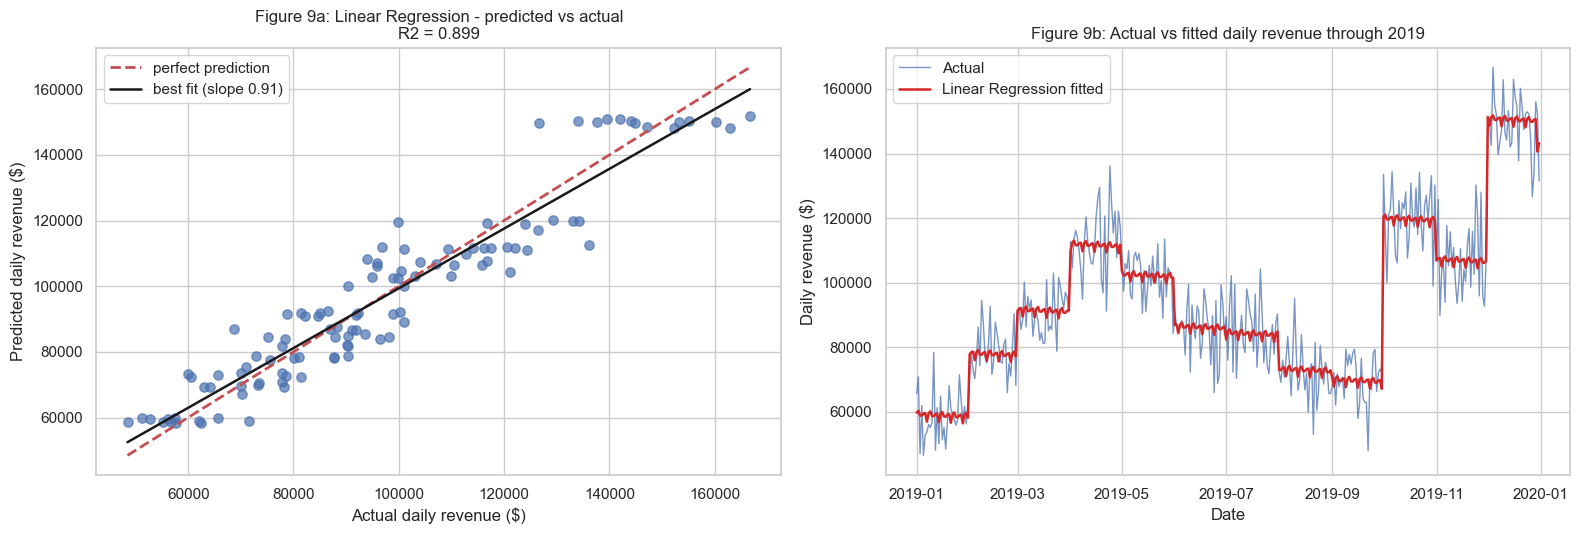

residual mean : $366
residual std  : $8,931
improvement over the mean-baseline RMSE: 68.4%


In [38]:
best_name = daily_results.loc[daily_results["Test R2"].idxmax(), "Algorithm"]
best_model = fitted_daily[best_name]
pred_te = best_model.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].scatter(y_te, pred_te, alpha=0.7, s=45)
lims = [min(y_te.min(), pred_te.min()), max(y_te.max(), pred_te.max())]
axes[0].plot(lims, lims, "r--", linewidth=2, label="perfect prediction")
fit = np.polyfit(y_te, pred_te, 1)
axes[0].plot(lims, np.polyval(fit, lims), "k-", linewidth=1.8,
             label=f"best fit (slope {fit[0]:.2f})")
axes[0].set_xlabel("Actual daily revenue ($)")
axes[0].set_ylabel("Predicted daily revenue ($)")
axes[0].set_title(f"Figure 9a: {best_name} - predicted vs actual\n"
                  f"R2 = {r2_score(y_te, pred_te):.3f}")
axes[0].legend()

full_pred = best_model.predict(X_daily)
axes[1].plot(daily["Date"], y_daily, label="Actual", linewidth=1, alpha=0.75)
axes[1].plot(daily["Date"], full_pred, label=f"{best_name} fitted", linewidth=1.8, color="tab:red")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily revenue ($)")
axes[1].set_title("Figure 9b: Actual vs fitted daily revenue through 2019")
axes[1].legend()

plt.tight_layout()
plt.show()

resid = y_te - pred_te
print(f"residual mean : ${resid.mean():,.0f}")
print(f"residual std  : ${resid.std():,.0f}")
print(f"improvement over the mean-baseline RMSE: "
      f"{1 - np.sqrt(mean_squared_error(y_te, pred_te))/baseline_rmse:.1%}")

**This is the model that actually answers RQ7 usefully.**

Linear Regression achieved a test R² of approximately 0.90 with an RMSE of about $8,900, compared with a mean daily revenue of $94,475. This corresponds to a typical prediction error of less than 10% of daily revenue and represents a substantial improvement over the baseline model that always predicts the average daily revenue. Cross-validation produced consistent results, suggesting that the model generalises well rather than relying on a favourable train-test split.

Among the models tested, Linear Regression achieved the best performance. With only 365 daily observations, the relationship between the calendar features and daily revenue is relatively smooth, and the additional flexibility of the tree-based models did not improve predictive accuracy. In this case, the simpler linear model was sufficient to capture the underlying pattern.

Figure 9b shows that the fitted values follow the overall seasonal trend closely, including the increase in April, the mid-year decline, and the strong rise in December. The largest prediction errors occur on days with unusually high or low sales, indicating that short-term fluctuations in customer purchasing behaviour cannot be explained by calendar features alone.

Overall, the answer to RQ7 depends on the level of aggregation. At the order-line level, contextual variables provide almost no predictive power (R² ≈ 0.00), while including product identity makes the prediction task almost deterministic because each product has a fixed unit price. At the daily level, however, aggregating thousands of individual transactions reveals clear seasonal patterns, allowing daily revenue to be predicted with an R² of approximately 0.90.

## 7. Feature Importance Analysis

### 7.1 RQ8 — which features matter at the order-line level?

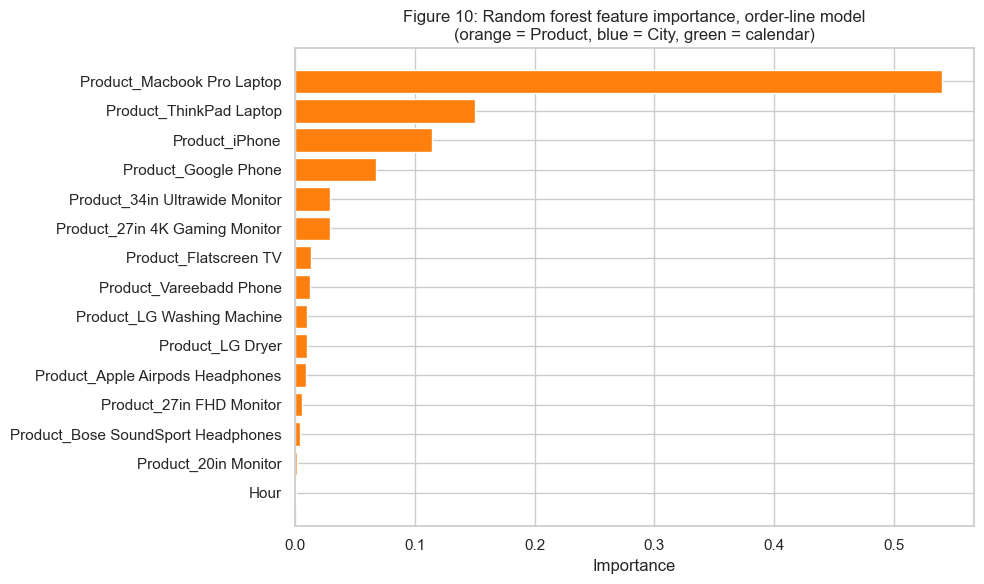

Importance grouped by feature family:
Product identity                   0.9987
Calendar (Hour/Month/DayOfWeek)    0.0012
City                               0.0001


In [33]:
rf_line = fit_c["Random Forest"]
imp_line = pd.Series(rf_line.feature_importances_, index=X_c.columns).sort_values(ascending=False)

top = imp_line.head(15).iloc[::-1]
plt.figure(figsize=(10, 6))
colors = ["tab:orange" if n.startswith("Product_") else
          "tab:blue" if n.startswith("City_") else "tab:green" for n in top.index]
plt.barh(top.index, top.values, color=colors)
plt.title("Figure 10: Random forest feature importance, order-line model\n"
          "(orange = Product, blue = City, green = calendar)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

grouped = pd.Series({
    "Product identity": imp_line[[i for i in imp_line.index if i.startswith("Product_")]].sum(),
    "City": imp_line[[i for i in imp_line.index if i.startswith("City_")]].sum(),
    "Calendar (Hour/Month/DayOfWeek)": imp_line[["Hour", "Month", "DayOfWeek"]].sum(),
}).sort_values(ascending=False)
print("Importance grouped by feature family:")
print((grouped / grouped.sum()).round(4).to_string())

At the order-line level, product identity contributes almost all of the model's predictive power, while the city and calendar features make only a negligible contribution.

The most important features correspond to the higher-priced products, including the MacBook Pro Laptop, ThinkPad Laptop, iPhone and Google Phone. This reflects the large differences in unit price across products, making product identity highly informative for predicting order value.

These results are consistent with the findings in Section 6.2. From the model's perspective, product identity is by far the most informative feature, whereas the city and calendar variables provide very little additional predictive information.

### 7.2 Which features drive daily revenue?

/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarni

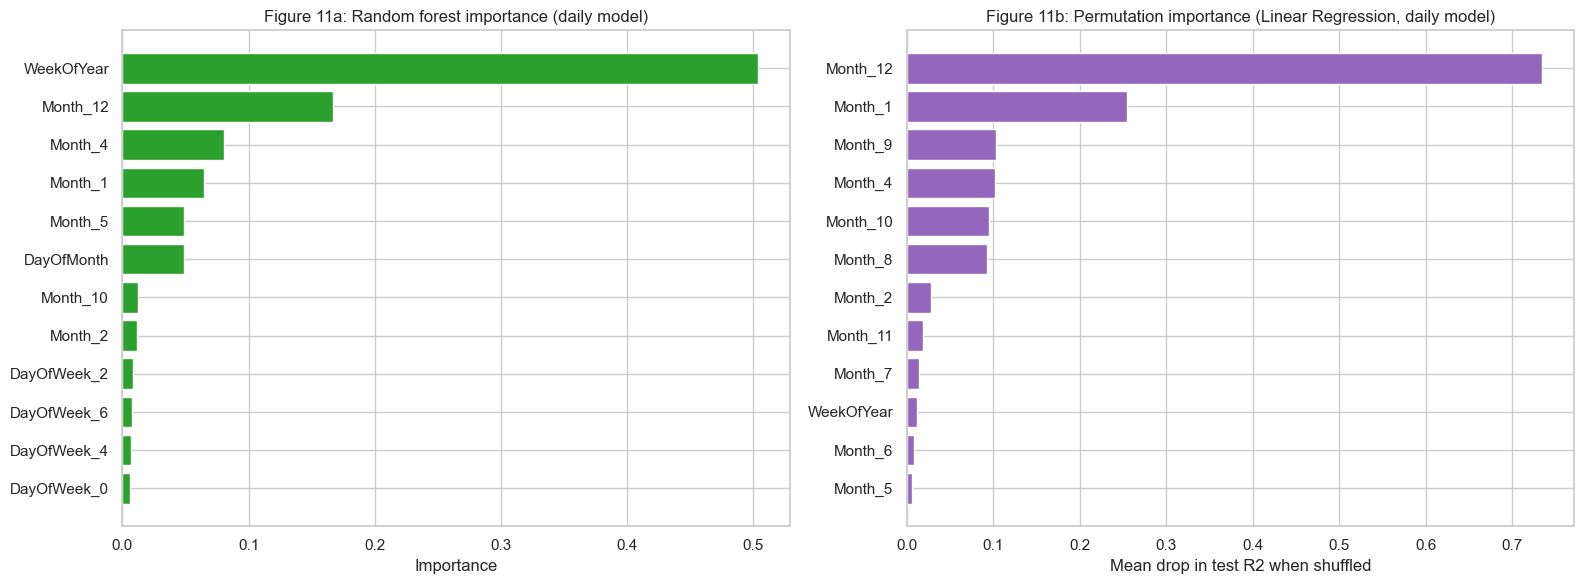

Top 8 by permutation importance:
Month_12    0.7347
Month_1     0.2544
Month_9     0.1032
Month_4     0.1023
Month_10    0.0952
Month_8     0.0929
Month_2     0.0281
Month_11    0.0186


In [43]:
rf_daily = fitted_daily["Random Forest"]
imp_daily = pd.Series(rf_daily.feature_importances_, index=X_daily.columns).sort_values(ascending=False)

# Permutation importance on the best (linear) model - more trustworthy than impurity importance,
# and it measures how much test performance actually degrades when a feature is shuffled.
perm = permutation_importance(best_model, X_te, y_te, n_repeats=30, random_state=42, scoring="r2")
perm_s = pd.Series(perm.importances_mean, index=X_daily.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

t1 = imp_daily.head(12).iloc[::-1]
axes[0].barh(t1.index, t1.values, color="tab:green")
axes[0].set_title("Figure 11a: Random forest importance (daily model)")
axes[0].set_xlabel("Importance")

t2 = perm_s.head(12).iloc[::-1]
axes[1].barh(t2.index, t2.values, color="tab:purple")
axes[1].set_title(f"Figure 11b: Permutation importance ({best_name}, daily model)")
axes[1].set_xlabel("Mean drop in test R2 when shuffled")

plt.tight_layout()
plt.show()

print("Top 8 by permutation importance:")
print(perm_s.head(8).round(4).to_string())

Both importance measures indicate that seasonal timing is the dominant source of predictive information in the daily model. Random Forest importance places greater emphasis on WeekOfYear, whereas permutation importance assigns the highest importance to the month indicators. In both cases, DayOfWeek contributes relatively little to model performance.

This is consistent with the findings in Section 3.5, where daily revenue varied much more across seasons than across weekdays. The results suggest that seasonal patterns are substantially more informative than weekday effects for predicting daily revenue.

The two importance measures should be interpreted together. Impurity-based importance can favour high-cardinality variables such as WeekOfYear, while permutation importance measures the reduction in predictive performance when a feature is randomly shuffled. Although the two methods rank individual variables differently, both identify seasonal features as the dominant predictors, increasing confidence in the overall conclusion.

## 8. Summary of findings

This section records **what the analysis found**, as a factual reference for interpretation. Each
claim is traceable to a numbered figure or statistical test above.

| RQ | Question | Finding | Evidence |
|---|---|---|---|
| 1 | Highest-revenue month | **December**, $4.61m (13.4% of $34.49m annual); 2.53x the January trough | Fig. 1a-b |
| 2 | Top city | **San Francisco**, $8.26m (24.0%); 1.52x Los Angeles | Fig. 2a-b |
| 3 | Top products | Units: **AAA Batteries** (31,017). Revenue: **Macbook Pro** ($8.04m, 23.3%). 8 of 19 products = 80% of revenue | Fig. 3a-c |
| 4 | Peak order time | **19:00** (12,377 orders), secondary peak at 12:00; bimodal daily curve | Fig. 4a-b |
| 5 | Price vs frequency | **Yes** — Spearman rho = -0.777, p < 0.001; power law with exponent -0.45 | Fig. 6a-b |
| 6 | Co-purchased products | **Phones + matching cables**: Google Phone + USB-C (lift 1.47), iPhone + Lightning (lift 1.22) | Fig. 8a-b |
| 7 | Can ML predict revenue? | **Depends on grain**: order-line context R² = 0.00; daily aggregate R² = 0.90 | Fig. 9a-b |
| 8 | Most important features | Order-line: **product identity** (~99%). Daily: **seasonal position**; day of week irrelevant | Fig. 10, 11a-b |

### Cross-cutting observations

1. Sales is a derived variable rather than an independently measured outcome, since it is calculated as Quantity × Price Each (subject only to floating-point precision). Consequently, any model that includes both variables achieves an almost perfect R², which reflects information leakage rather than genuine predictive performance.

2. Transaction volume, rather than individual order value, explains most of the observed patterns. Order value showed little or no association with city (ANOVA, p > 0.05) or hour (Spearman's ρ ≈ 0). The higher revenue observed in December, San Francisco and around 19:00 is primarily explained by a larger number of transactions rather than higher spending per order.

3. Association rules should be evaluated using lift rather than frequency alone. For example, Wired Headphones and iPhone appear together frequently, but their lift is only 0.64, indicating that they co-occur less often than would be expected if purchases were independent. Ranking product pairs by frequency alone would therefore produce misleading cross-selling recommendations.

4. On the daily dataset, Linear Regression achieved the best predictive performance. With only 365 daily observations, the additional flexibility of Random Forest and Gradient Boosting did not improve prediction accuracy. This suggests that a simpler linear model was sufficient to capture the seasonal patterns present in the data.

### Limitations

- The analysis covers only one year of data (2019). As a result, the observed seasonal patterns are based on a single annual cycle. For example, the December peak may reflect both seasonal demand and year-specific events, and long-term trends cannot be assessed.

- Most orders contain only a single product (96.2%). Consequently, all association rules have very low support (below 0.6%). Although the identified rules are plausible, they are based on a relatively small proportion of transactions and should therefore be interpreted with caution.

- The dataset does not include customer identifiers. As a result, customer-level analyses, such as repeat purchasing behaviour, customer lifetime value, and cohort analysis, cannot be performed.

- The analysis for RQ5 is observational rather than experimental. It compares products with different prices but does not observe changes in the price of the same product over time. Therefore, the results cannot be interpreted as evidence of causal price elasticity.

- The dataset contains revenue but not cost information. Consequently, the analysis evaluates sales performance rather than profitability. Products generating the highest revenue may not necessarily contribute the highest profit if their profit margins differ substantially.